In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


# Cluster 

In [3]:
HumanCT_Z2_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/Human.Cluster.Log2Mean.Z1clip5.Z2.clip3.Dec30.csv", index_col=0)
HumanCT_Z2_HCT.columns = HumanCT_Z2_HCT.columns.astype(int)

##### Load GW

In [4]:
GeneWeightDIR = "../dat/GeneWeights/"
Bias_Save_Dict = "../dat/Bias_Feb27_2025/"
if not os.path.exists(Bias_Save_Dict): # make dir if not exists
    os.makedirs(Bias_Save_Dict)


#### ASD Bias

In [5]:
#ASD_GW = pd.read_csv("../../ASD_Circuits/dat/Unionize_bias/Spark_Meta_EWS.GeneWeight.csv", header=None)
#ASD_GW = dict(zip(ASD_GW[0].values, ASD_GW[1].values))

In [7]:
# ASD_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT_clip5, ASD_GW, Method = 1)
# ASD_Z2_Bias = AnnotateCTDat(ASD_Z2_Bias, Anno)
# ASD_Z2_Bias.to_csv("{}/HCT.ASD61.Z2.HCT.csv".format(Bias_Save_Dict))

In [8]:
# SuperClusterBias_BoxPlot(ASD_Z2_Bias, "ASD HCT")

### HIQ & LIQ ASD

In [9]:

HIQ_GW = Fil2Dict("{}/HIQ.top61.nopLI.gw".format(GeneWeightDIR))
LIQ_GW = Fil2Dict("{}/LIQ.top61.nopLI.gw".format(GeneWeightDIR))
print(len(HIQ_GW), len(LIQ_GW))

42 49


In [10]:
HIQ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, HIQ_GW, Method = 1)
HIQ_Z2_Bias = AnnotateCTDat(HIQ_Z2_Bias, Anno)
HIQ_Z2_Bias.to_csv("{}/HCT.ASD61.HIQ.Z2.HCT.csv".format(Bias_Save_Dict))

LIQ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, LIQ_GW, Method = 1)
LIQ_Z2_Bias = AnnotateCTDat(LIQ_Z2_Bias, Anno)
LIQ_Z2_Bias.to_csv("{}/HCT.ASD61.LIQ.Z2.HCT.csv".format(Bias_Save_Dict))

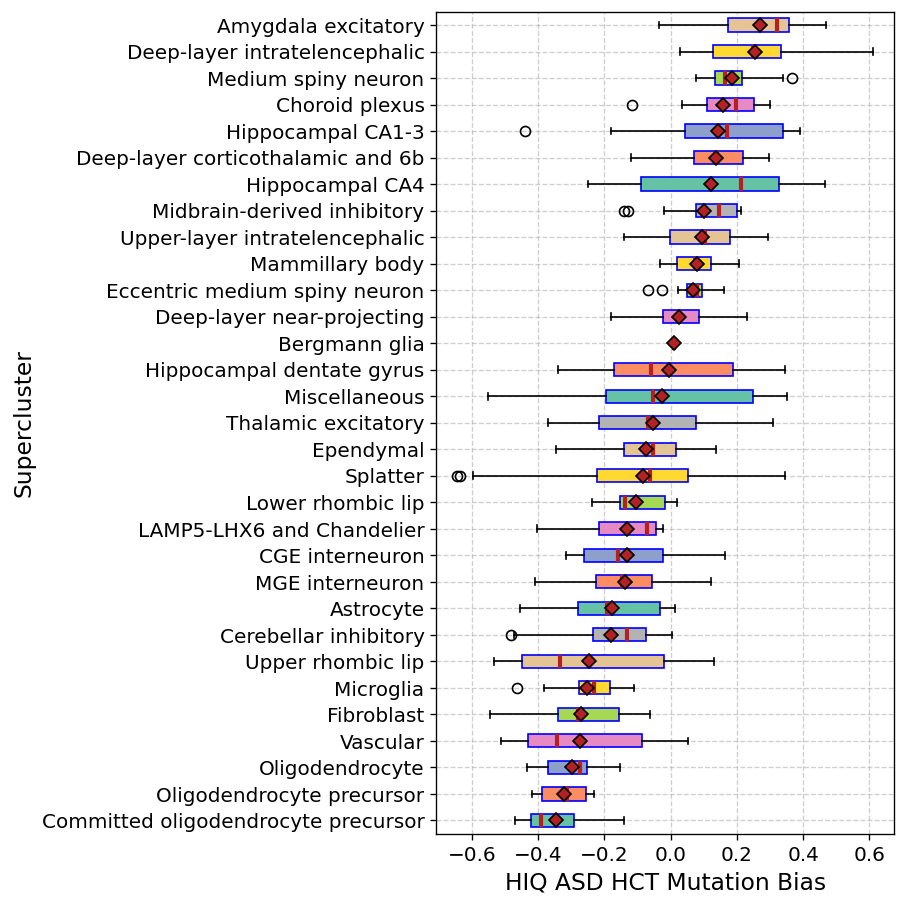

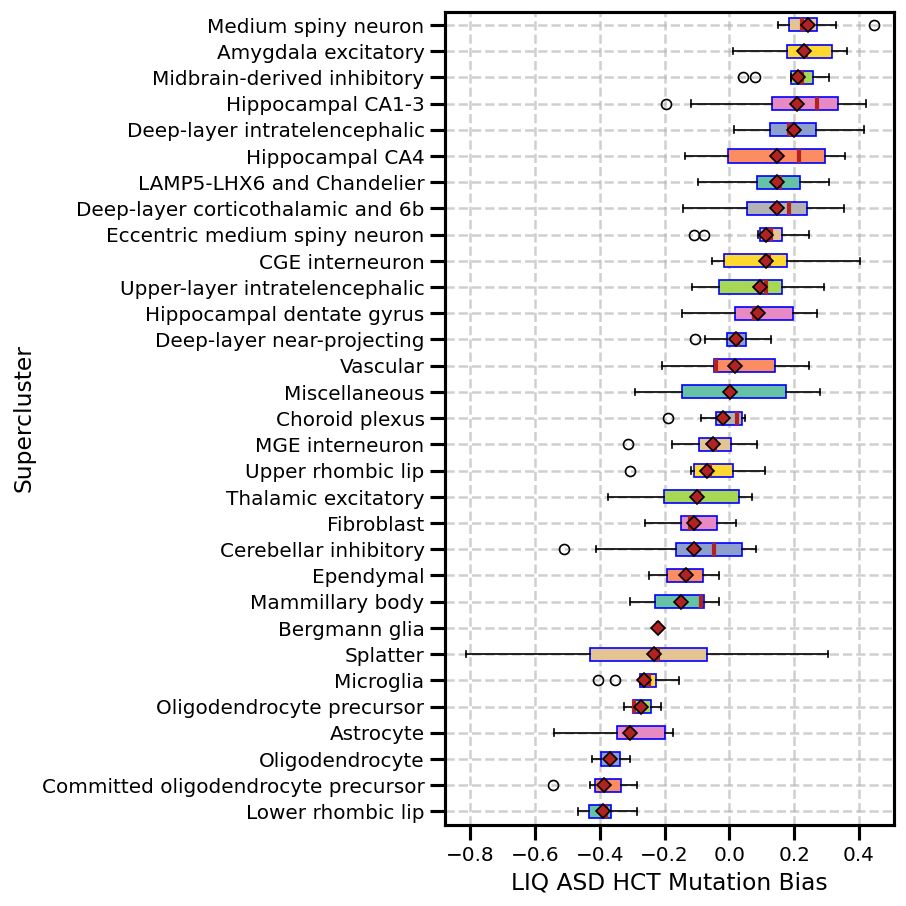

In [11]:
SuperClusterBias_BoxPlot(HIQ_Z2_Bias, "HIQ ASD HCT")
SuperClusterBias_BoxPlot(LIQ_Z2_Bias, "LIQ ASD HCT")

## SCZ Bias

In [12]:
SCZ_GW = Fil2Dict("{}/SCZ_MutCount_61.gw".format(GeneWeightDIR))

In [13]:
SCZ_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, SCZ_GW, Method = 1)
SCZ_Z2_Bias = AnnotateCTDat(SCZ_Z2_Bias, Anno)
SCZ_Z2_Bias.to_csv("{}/HCT.SCZ61.Z2.HCT.csv".format(Bias_Save_Dict))

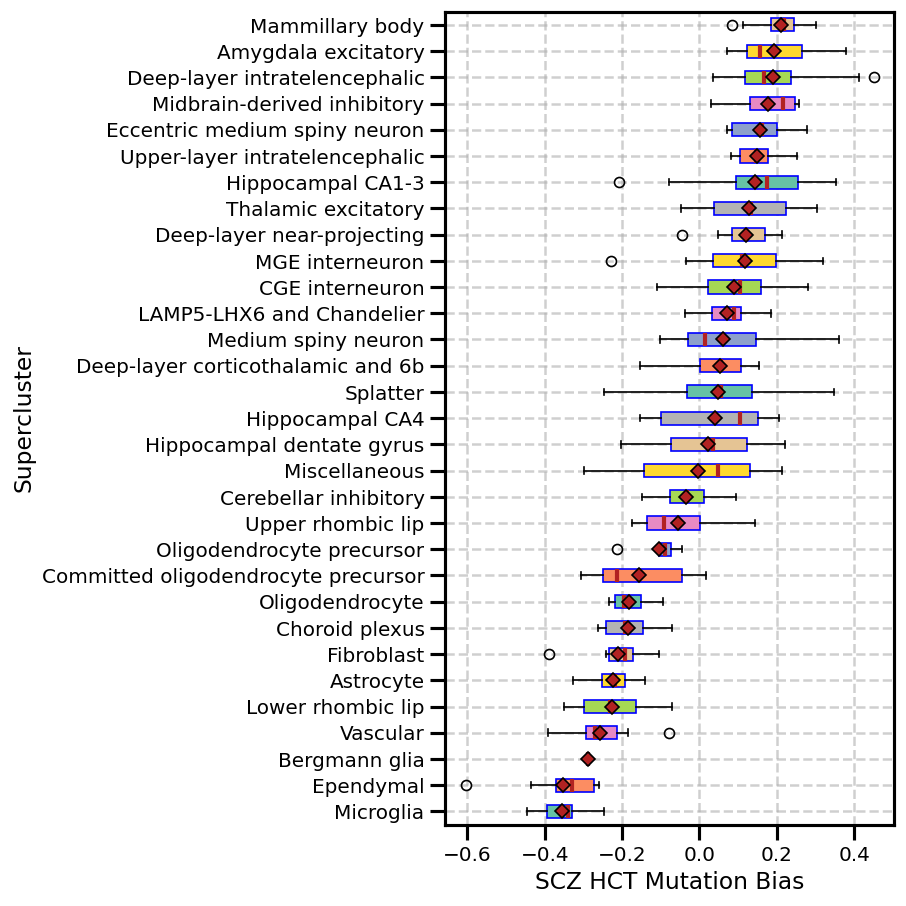

In [14]:
SuperClusterBias_BoxPlot(SCZ_Z2_Bias, "SCZ HCT")

## 22q.11 Bias

In [15]:
X22q_GW = Fil2Dict("../dat/GeneWeights/X22q.gw.csv")
X22q_GW_Mouse = Fil2Dict("{}/X22q.mousemodel.gw.csv".format(GeneWeightDIR))

In [16]:
X22q_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, X22q_GW, Method = 1)
X22q_Z2_Bias = AnnotateCTDat(X22q_Z2_Bias, Anno)
X22q_Z2_Bias.to_csv("{}/HCT.X22q.Z2.HCT.csv".format(Bias_Save_Dict))


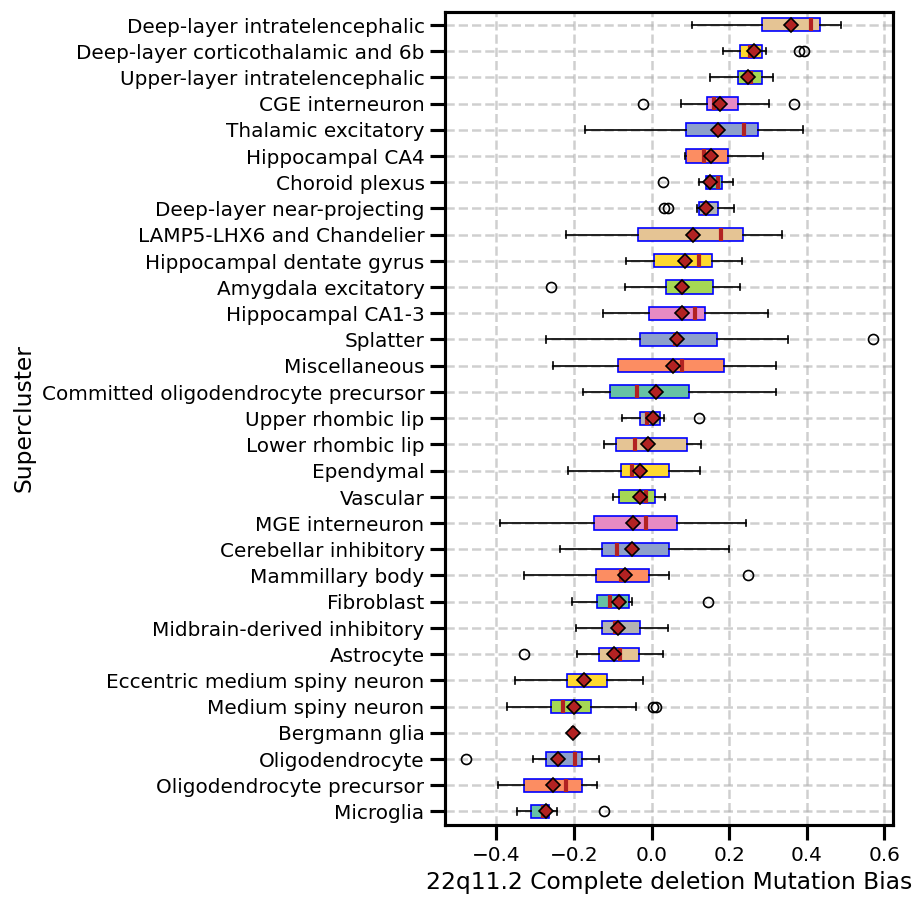

In [17]:
SuperClusterBias_BoxPlot(X22q_Z2_Bias, "22q11.2 Complete deletion")

In [18]:
X22q_Z2_Mouse_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, X22q_GW_Mouse, Method = 1)
X22q_Z2_Mouse_Bias = AnnotateCTDat(X22q_Z2_Mouse_Bias, Anno)
X22q_Z2_Mouse_Bias.to_csv("{}/HCT.X22q.mousemodel.Z2.HCT.csv".format(Bias_Save_Dict))

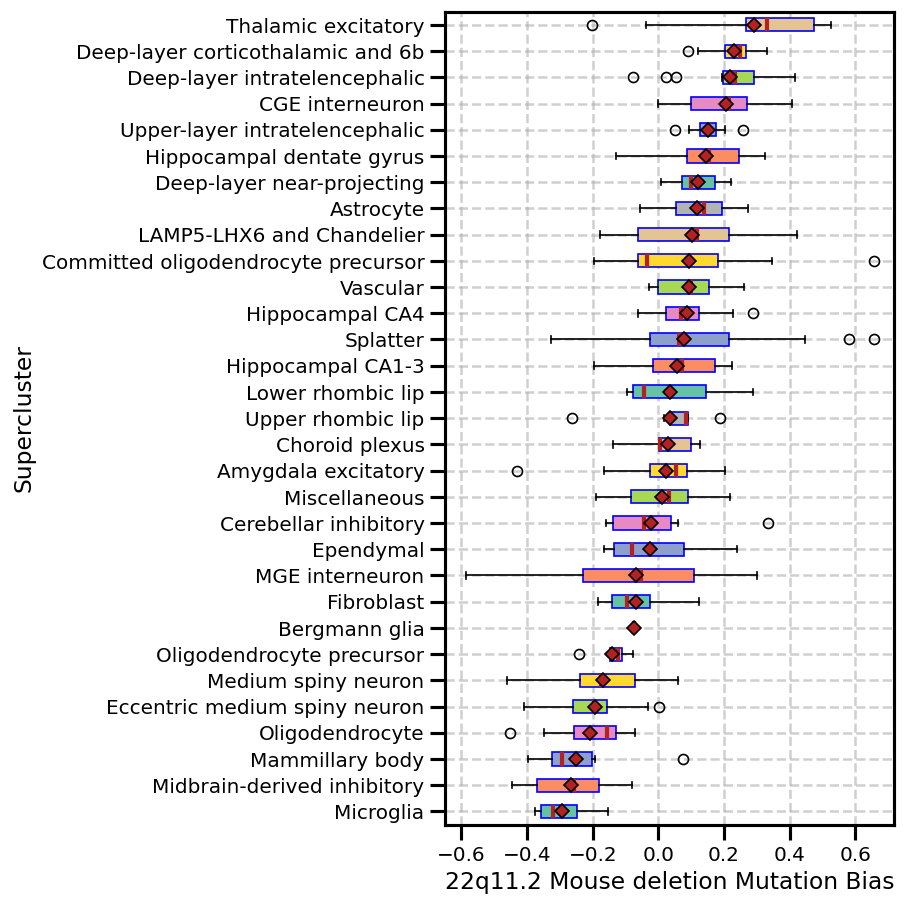

In [19]:
SuperClusterBias_BoxPlot(X22q_Z2_Mouse_Bias, "22q11.2 Mouse deletion")

### DDD

In [26]:
DDD_top61_GW = Fil2Dict("{}/DDD.top61.gw.csv".format(GeneWeightDIR))
DDD_hc_Bias_top61 = AvgCTZ_Weighted(HumanCT_Z2_HCT, DDD_top61_GW, Method = 1)
DDD_hc_Bias_top61 = AnnotateCTDat(DDD_hc_Bias_top61, Anno)
DDD_hc_Bias_top61.to_csv("{}/HCT.DDDHC.Z2.HCT.top61.csv".format(Bias_Save_Dict))

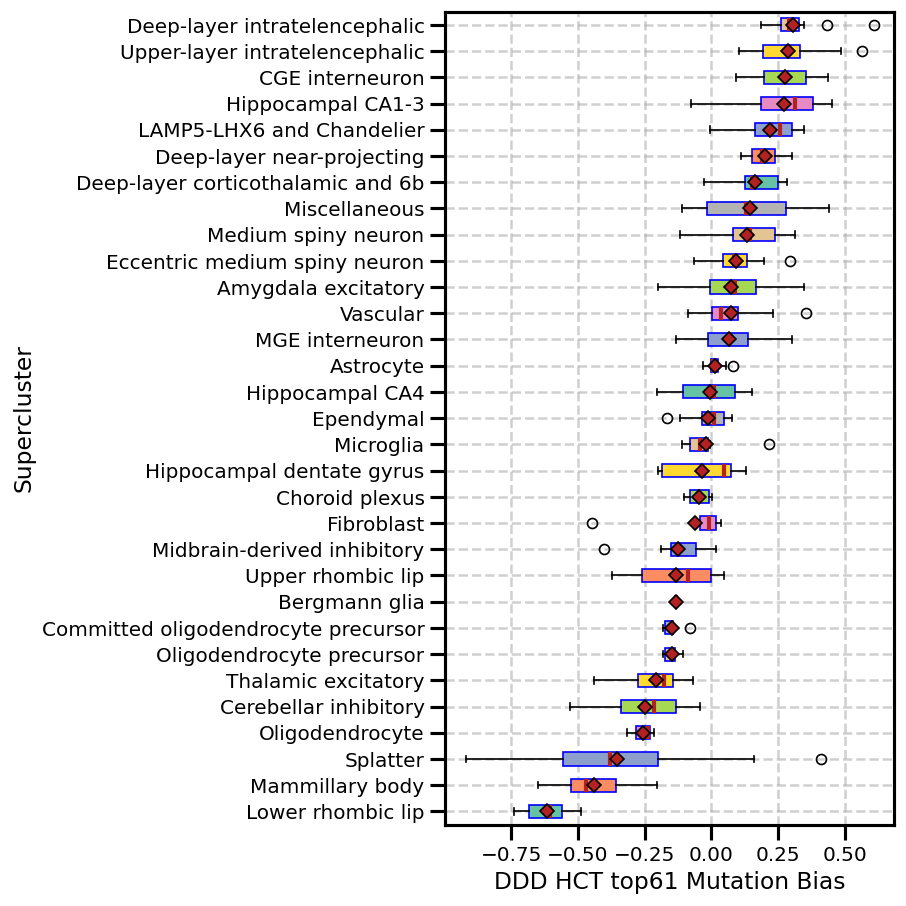

In [27]:
SuperClusterBias_BoxPlot(DDD_hc_Bias_top61, "DDD HCT top61")

In [28]:
DDD_hc_GW = Fil2Dict("{}/DDD.hc.gw.csv".format(GeneWeightDIR))
DDD_hc_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, DDD_hc_GW, Method = 1)
DDD_hc_Bias = AnnotateCTDat(DDD_hc_Bias, Anno)
DDD_hc_Bias.to_csv("{}/HCT.DDDHC.Z2.HCT.csv".format(Bias_Save_Dict))

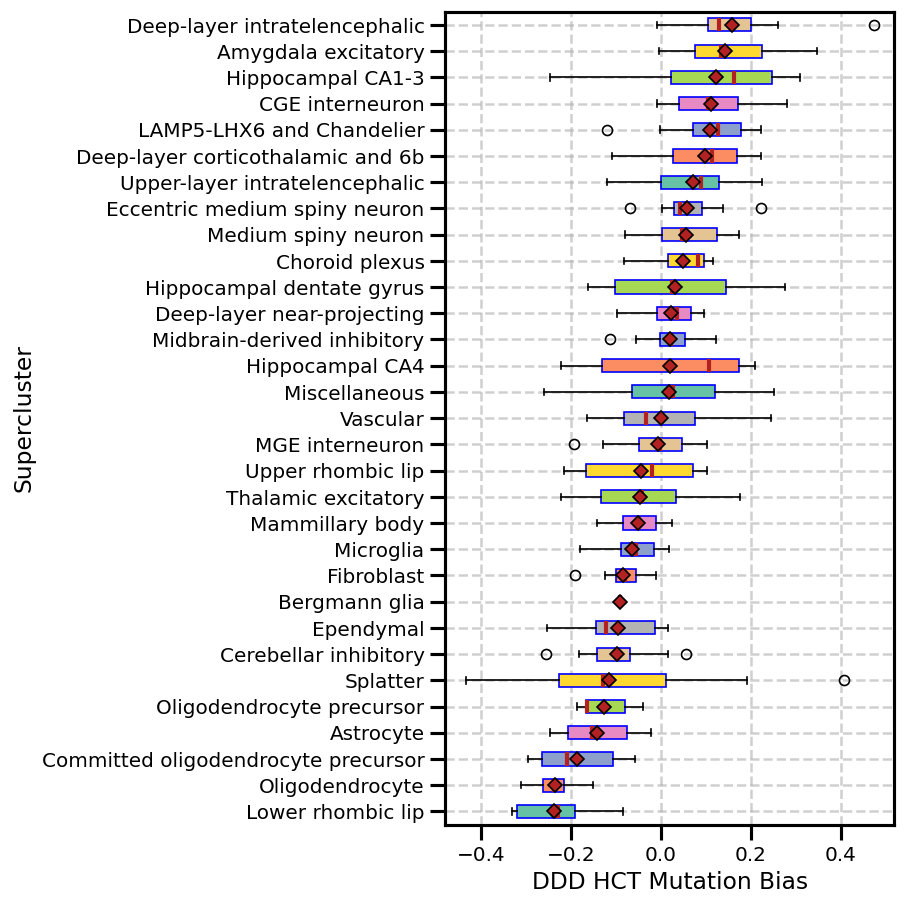

In [29]:
SuperClusterBias_BoxPlot(DDD_hc_Bias, "DDD HCT")

#### VNR

In [30]:
topN = 61
VNR_Pos_GW = Fil2Dict("{}/UKBB_VNR_Pos_GW_{}.csv".format(GeneWeightDIR, topN))
VNR_Neg_GW = Fil2Dict("{}/UKBB_VNR_Neg_GW_{}.csv".format(GeneWeightDIR, topN))
VNR_Pos_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, VNR_Pos_GW, Method = 1)
VNR_Pos_Bias = AnnotateCTDat(VNR_Pos_Bias, Anno)
VNR_Neg_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, VNR_Neg_GW, Method = 1)
VNR_Neg_Bias = AnnotateCTDat(VNR_Neg_Bias, Anno)
VNR_Pos_Bias.to_csv("{}/CTBias.VNR.Pos.top61.csv".format(Bias_Save_Dict))
VNR_Neg_Bias.to_csv("{}/CTBias.VNR.Neg.top61.csv".format(Bias_Save_Dict))

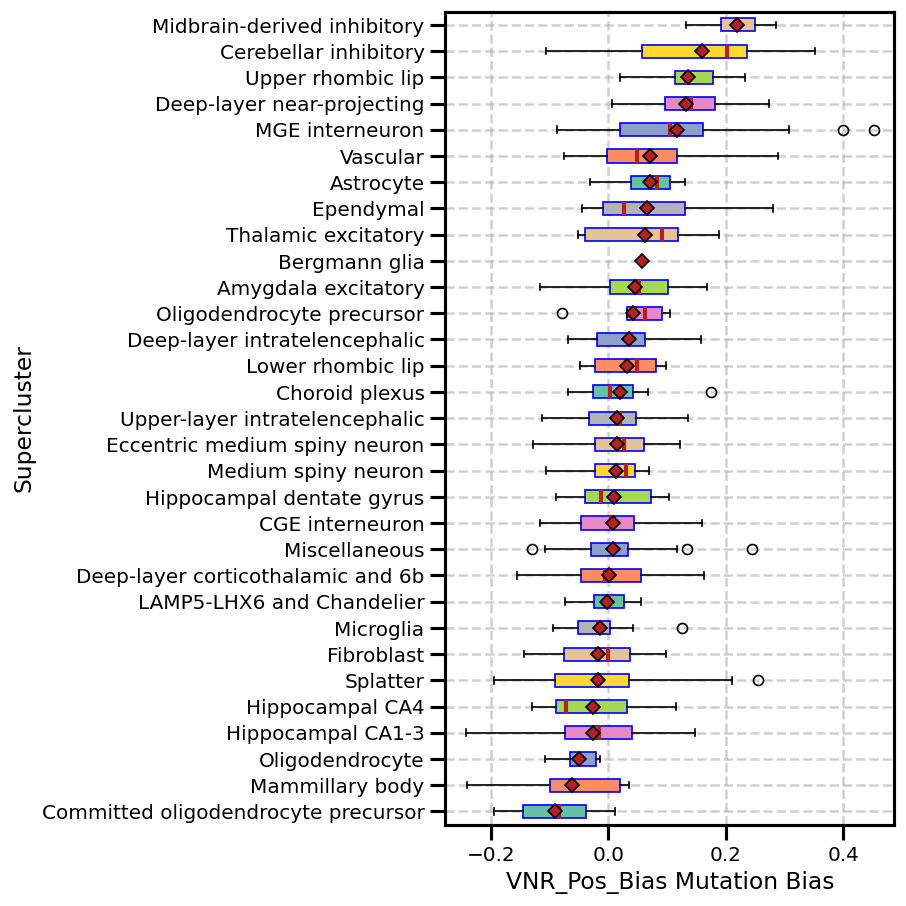

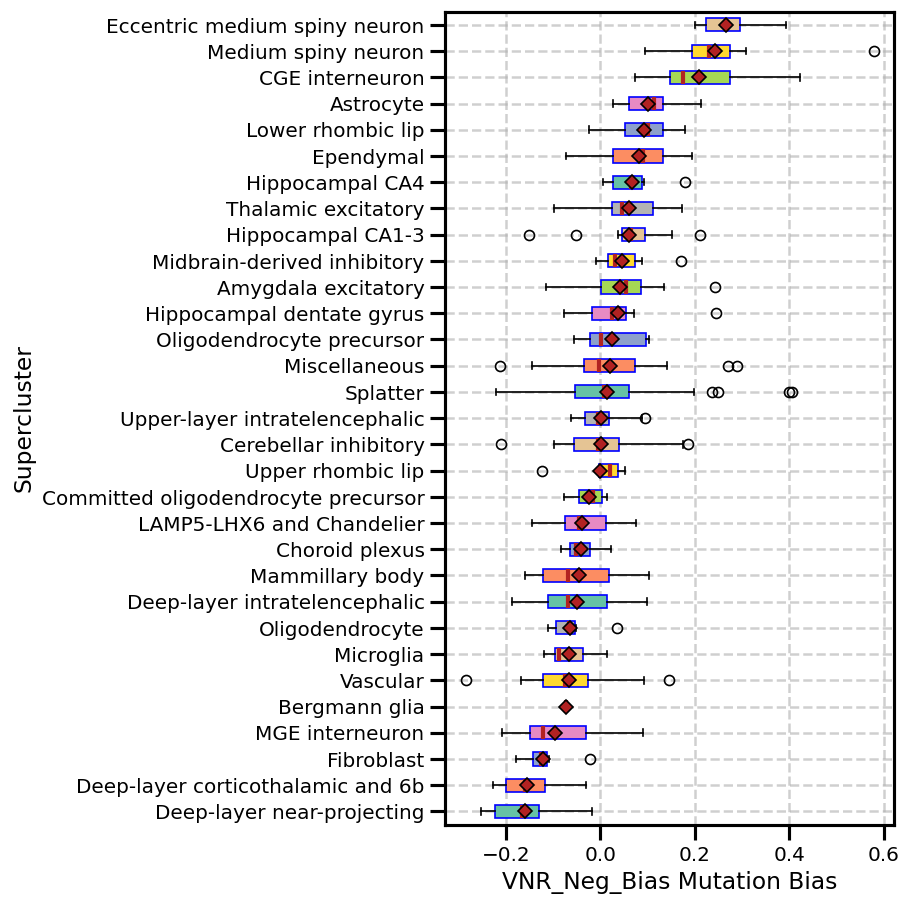

In [31]:
SuperClusterBias_BoxPlot(VNR_Pos_Bias, "VNR_Pos_Bias")
SuperClusterBias_BoxPlot(VNR_Neg_Bias, "VNR_Neg_Bias")

## BP

In [33]:
BP_GW = Fil2Dict("/home/jw3514/Work/CellType_Psy/dat/Archive/Bipolar.top61.gw.csv")
BP_Z2_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, BP_GW, Method = 1)
BP_Z2_Bias = AnnotateCTDat(BP_Z2_Bias, Anno)
#BP_Z2_Bias.to_csv("../dat/Bias/CTBias.BP.Z2.HCT.csv")
BP_Z2_Bias.to_csv("{}/HCT.BP.Z2.HCT.csv".format(Bias_Save_Dict))


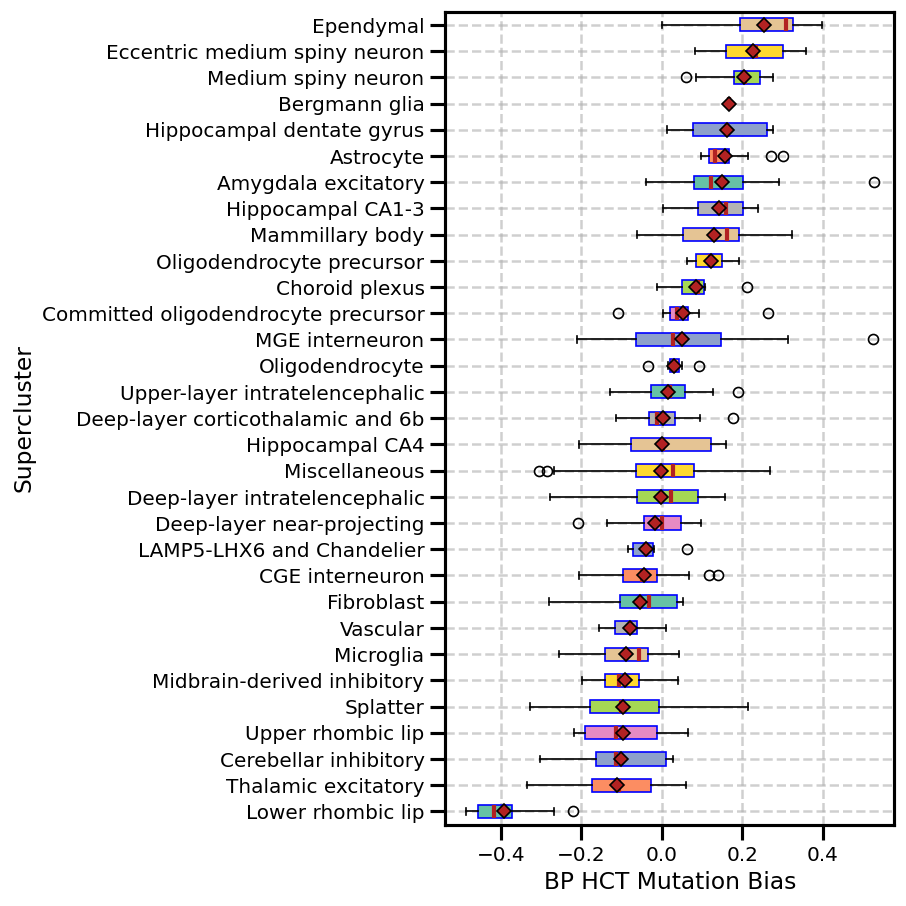

In [34]:
SuperClusterBias_BoxPlot(BP_Z2_Bias, "BP HCT")

## CNVs

In [35]:
genes_3q29 = [
    "BDH1",       # 3-hydroxybutyrate dehydrogenase 1
    "FBXO45",     # F-box protein 45
    "SENP5",      # SUMO specific peptidase 5
    "UBXN7",      # UBX domain protein 7
    "WDR53",      # WD repeat domain 53
    "CEP19",      # centrosomal protein 19
    "DLG1",       # discs large MAGUK scaffold protein 1
    "DYNLT2B",    # dynein light chain Tctex-type 2B
    "MELTF",      # melanotransferrin
    "NRROS",      # negative regulator of reactive oxygen species
    "NCBP2",      # nuclear cap binding protein subunit 2
    "PAK2",       # p21 (RAC1) activated kinase 2
    "PCYT1A",     # phosphate cytidylyltransferase 1A, choline
    "PIGX",       # phosphatidylinositol glycan anchor biosynthesis class X
    "PIGZ",       # phosphatidylinositol glycan anchor biosynthesis class Z
    "RNF168",     # ring finger protein 168
    "SMCO1",      # single-pass membrane protein with coiled-coil domains 1
    "SLC51A",     # solute carrier family 51 subunit alpha
    "TFRC",       # transferrin receptor
    "TM4SF19",    # transmembrane 4 L six family member 19
    "ZDHHC19"     # zinc finger DHHC-type palmitoyltransferase 19
]
genes_3q29_entrez = [int(GeneSymbol2Entrez[x]) for x in genes_3q29 if x in GeneSymbol2Entrez]
genes_3q29_GW = dict(zip(genes_3q29_entrez, [1]*len(genes_3q29_entrez)))
Dict2Fil(genes_3q29_GW, "/home/jw3514/Work/CellType_Psy/dat/GeneWeights/3q29.gw.csv")
genes_3q29_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, genes_3q29_GW, Method = 1)
genes_3q29_Bias = AnnotateCTDat(genes_3q29_Bias, Anno)
#genes_3q29_Bias.to_csv("../dat/Bias/CTBias.3q29.Z2.HCT.csv")
genes_3q29_Bias.to_csv("{}/HCT.3q29.Z2.HCT.csv".format(Bias_Save_Dict))

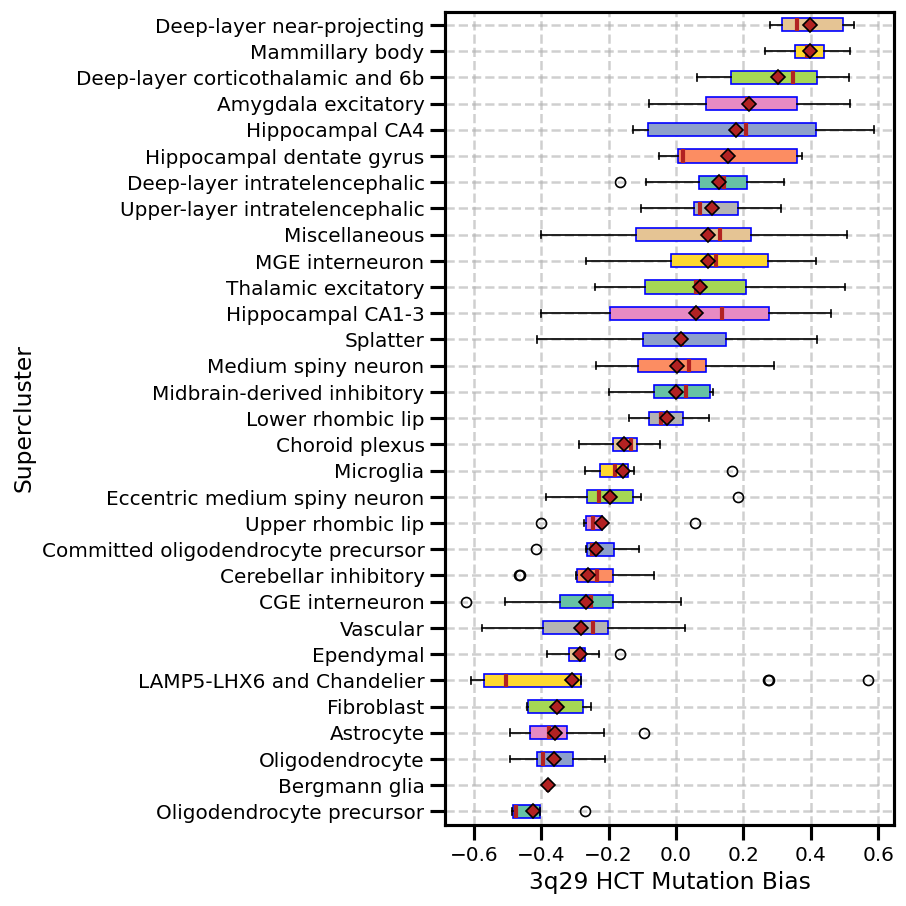

In [36]:
SuperClusterBias_BoxPlot(genes_3q29_Bias, "3q29 HCT")

In [37]:
X16p_df = pd.read_excel("~/Work/data/13073_2021_972_MOESM2_ESM.xlsx", sheet_name="16p11.2")
Gene16p11 = X16p_df[X16p_df["Type"]=="protein_coding"]["Gene_name"].values
Gene16p11 = [int(GeneSymbol2Entrez[x]) for x in Gene16p11 if x in GeneSymbol2Entrez.keys()]
print(len(Gene16p11))
X16pGW = dict(zip(Gene16p11, [1]*len(Gene16p11)))
Dict2Fil(X16pGW, "/home/jw3514/Work/CellType_Psy/dat/GeneWeights/16p11.gw.csv")

39


In [38]:
genes_16p11_Bias = AvgCTZ_Weighted(HumanCT_Z2_HCT, X16pGW, Method = 1)
genes_16p11_Bias = AnnotateCTDat(genes_16p11_Bias, Anno)
#genes_16p11_Bias.to_csv("../dat/Bias/CTBias.16p11.Z2.HCT.csv")
genes_16p11_Bias.to_csv("{}/HCT.16p11.Z2.HCT.csv".format(Bias_Save_Dict))

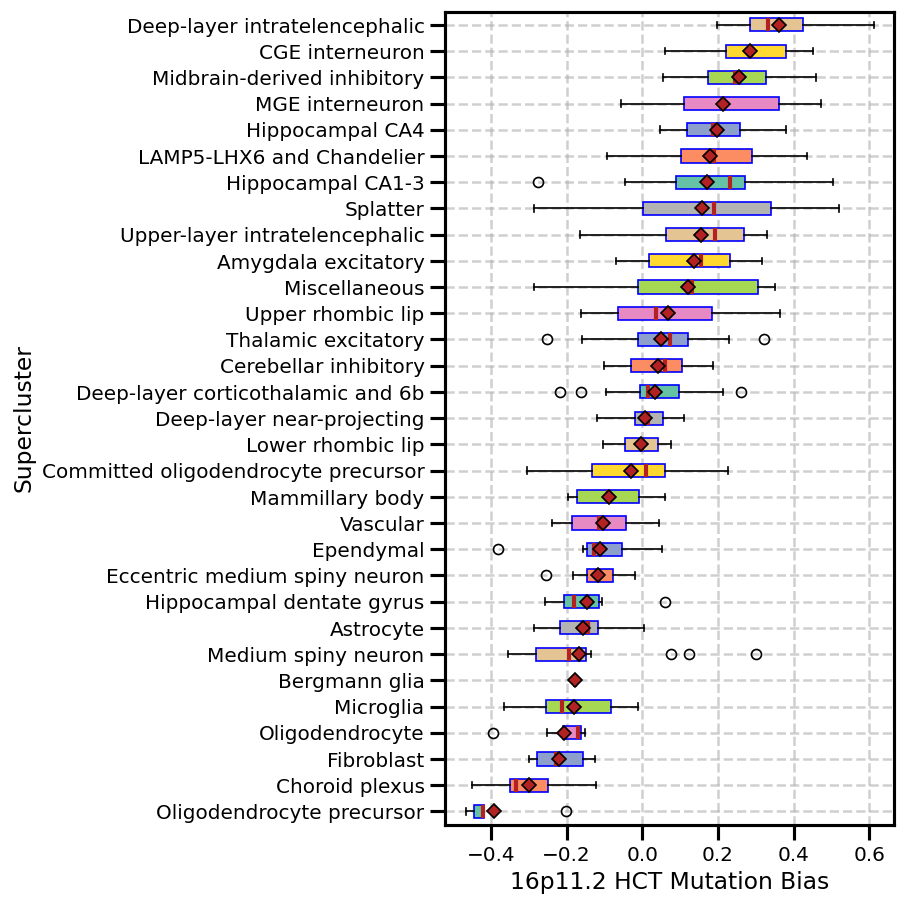

In [39]:
SuperClusterBias_BoxPlot(genes_16p11_Bias, "16p11.2 HCT")

In [40]:
print(len(genes_3q29_GW))
print(len(X16pGW))
print(len(X22q_GW))

21
39
46
